### Imports

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, Model, metrics
import numpy as np

In [58]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Definitions

In [59]:
# Path to your images folder
IMAGES_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/dividing_rf"

# --- Constants ---
INPUT_SHAPE = 200
LATENT_DIM = 8
N_CENTROIDS = 4
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-5

### Get train data

In [60]:
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split

# List all image file paths
image_files = [os.path.join(IMAGES_PATH, image) for image in os.listdir(IMAGES_PATH)]

# Split file paths into train and test
train_files, test_files = train_test_split(image_files, test_size=0.2, random_state=42)

def load_and_preprocess_image_tf(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])  # Explicitly set shape for resizing
    image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_dataset(file_list, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    ds = ds.map(load_and_preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

batch_size = 32
train_dataset = make_dataset(train_files, batch_size)
test_dataset = make_dataset(test_files, batch_size)

### Definition of the model

In [61]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

class ChannelLimitedVAE(Model):
    """
    VAE Convolucional con Limitación de Canal.
    VERSIÓN FINAL: Incluye compute_loss y test_step para un manejo correcto de la validación.
    """
    def __init__(self, latent_dim, gamma, initial_c=0.0, name="channel_limited_vae", **kwargs):
        super(ChannelLimitedVAE, self).__init__(name=name, **kwargs)
        
        self.latent_dim = latent_dim
        self.gamma = gamma
        self.capacity = tf.Variable(initial_c, trainable=False, dtype=tf.float32)

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

        # ---- El Encoder y Decoder permanecen sin cambios ----
        # ... (código del encoder y decoder es el mismo de la respuesta anterior)
        encoder_inputs = layers.Input(shape=(200, 200, 1))
        x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation="relu")(x)
        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
        self.encoder = Model(encoder_inputs, [z_mean, z_log_var], name="encoder")
        
        latent_inputs = layers.Input(shape=(latent_dim,))
        x = layers.Dense(13 * 13 * 256, activation="relu")(latent_inputs)
        x = layers.Reshape((13, 13, 256))(x)
        x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="valid")(x)
        x = layers.Cropping2D(cropping=((5, 4), (5, 4)))(x)
        decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
        self.decoder = Model(latent_inputs, decoder_outputs, name="decoder")


    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def reparameterize(self, z_mean, z_log_var):
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def call(self, inputs):
        z_mean, z_log_var = self.encoder(inputs)
        z = self.reparameterize(z_mean, z_log_var)
        reconstruction = self.decoder(z)
        return reconstruction, z_mean, z_log_var
    
    # --- NUEVO MÉTODO PARA CENTRALIZAR LA LÓGICA DE PÉRDIDA ---
    def compute_loss(self, data):
        # Desempaquetamos los datos de entrada
        if isinstance(data, tuple):
            data = data[0]
        
        # Obtenemos las salidas del modelo
        reconstruction, z_mean, z_log_var = self(data, training=False)
        
        # Calculamos las pérdidas
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=(1, 2),
            )
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        
        # Pérdida total
        kl_capacity_loss = self.gamma * tf.abs(kl_loss - self.capacity)
        total_loss = reconstruction_loss + kl_capacity_loss
        
        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

    def train_step(self, data):
        # Desempaquetamos los datos de entrada
        if isinstance(data, tuple):
            data = data[0]
            
        with tf.GradientTape() as tape:
            # Reutilizamos la lógica de compute_loss, pero dentro del GradientTape
            reconstruction, z_mean, z_log_var = self(data, training=True)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            
            kl_capacity_loss = self.gamma * tf.abs(kl_loss - self.capacity)
            total_loss = reconstruction_loss + kl_capacity_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Actualizamos las métricas
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {m.name: m.result() for m in self.metrics}
    
    # --- NUEVO MÉTODO PARA EL PASO DE VALIDACIÓN ---
    def test_step(self, data):
        # Desempaquetamos los datos de entrada
        if isinstance(data, tuple):
            data = data[0]
        
        # Calculamos la pérdida usando nuestro método centralizado
        losses = self.compute_loss(data)

        # Actualizamos las métricas de validación
        self.total_loss_tracker.update_state(losses["loss"])
        self.reconstruction_loss_tracker.update_state(losses["reconstruction_loss"])
        self.kl_loss_tracker.update_state(losses["kl_loss"])
        
        # Devolvemos las métricas con el prefijo "val_"
        return {f"val_{m.name}": m.result() for m in self.metrics}

In [62]:
# --- Callback para el Annealing de la Capacidad (C) ---
class CapacityAnnealingCallback(tf.keras.callbacks.Callback):
    def __init__(self, C_max, num_epochs, C_start=0.0):
        super(CapacityAnnealingCallback, self).__init__()
        self.C_max = C_max
        self.C_start = C_start
        self.num_epochs = num_epochs
        # Calcula el incremento de C por época
        self.C_inc = (C_max - C_start) / num_epochs

    def on_epoch_end(self, epoch, logs=None):
        # Aumenta el valor de la capacidad C
        new_capacity = self.model.capacity.value() + self.C_inc
        self.model.capacity.assign(min(self.C_max, new_capacity))
        print(f"\nEpoch {epoch+1}: Capacity C updated to {self.model.capacity.numpy():.4f}")


# --- Configuración y Entrenamiento ---

# Tus datasets ya están definidos
# train_dataset = ...
# test_dataset = ...

# Hiperparámetros
LATENT_DIM = 32   # Dimensión del espacio latente
GAMMA = 50.0      # Factor de penalización gamma
EPOCHS = 50
C_MAX = 20      # Capacidad máxima a alcanzar
LEARNING_RATE = 1e-5

# Este código de entrenamiento ahora funcionará perfectamente
# Este código de entrenamiento ahora funcionará perfectamente
vae = ChannelLimitedVAE(latent_dim=LATENT_DIM, gamma=GAMMA, initial_c=0.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Compilamos SÓLO con el optimizador. Keras usará train_step y test_step
vae.compile(optimizer=optimizer)

capacity_callback = CapacityAnnealingCallback(C_max=C_MAX, num_epochs=EPOCHS)

history = vae.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=[capacity_callback]
)

print("¡Entrenamiento completado!")

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - kl_loss: 21.7505 - reconstruction_loss: 28571.3691 - total_loss: 29658.8906
Epoch 1: Capacity C updated to 0.4000
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - kl_loss: 21.6204 - reconstruction_loss: 28570.4023 - total_loss: 29651.4141 - val_val_kl_loss: 0.1838 - val_val_reconstruction_loss: 27776.2070 - val_val_total_loss: 27785.3984
Epoch 2/50
73/76 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 1.3686 - reconstruction_loss: 28236.8711 - total_loss: 28285.3145
Epoch 2: Capacity C updated to 0.8000
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - kl_loss: 1.3516 - reconstruction_loss: 28232.9277 - total_loss: 28280.5449 - val_val_kl_loss: 0.5045 - val_val_reconstruction_loss: 27831.0195 - val_val_total_loss: 27836.2441
Epoch 3/50
73/76 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.5179 - reconstruction_loss: 27967.0703 - total_loss: 27983.8223
Epoch 3: Capacity C updated to 1.2000
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - kl_loss: 0.5286 - reco

In [63]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE

# # Assuming `vae` is your trained ChannelLimitedVAE model and `train_dataset` is available.
# # Your original data loading code defined `batch_size`, we will use that.
# # batch_size = 32 

# print("Collecting latent vectors for visualization...")

# # 1. Collect latent vectors from the dataset
# # We'll use a subset of the training data for efficiency.
# num_images_to_plot = 1000 
# num_batches_to_take = num_images_to_plot // batch_size + 1

# latent_vectors = []

# # Loop through the dataset to get the latent representations
# for batch in train_dataset.take(num_batches_to_take):
#     # This is the key change: call the encoder from your 'vae' object.
#     # The encoder returns the mean (mu) and log variance (log_var). We only need mu for visualization.
#     mu, log_var = vae.encoder(batch) 
#     latent_vectors.append(mu.numpy())

# # Combine the lists of vectors into a single NumPy array
# latent_vectors = np.vstack(latent_vectors)[:num_images_to_plot]

# print(f"Collected {latent_vectors.shape[0]} latent vectors of dimension {latent_vectors.shape[1]}")

# # 2. Apply t-SNE to reduce dimensionality to 2D
# print("Applying t-SNE... (this may take a moment)")
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, init='pca', learning_rate='auto')
# latent_2d_tsne = tsne.fit_transform(latent_vectors)
# print("t-SNE finished.")

# # 3. Plot the 2D latent space
# plt.figure(figsize=(12, 10))
# plt.scatter(latent_2d_tsne[:, 0], latent_2d_tsne[:, 1], s=10, alpha=0.6)
# plt.title('2D Latent Space Visualization of Images (t-SNE)', fontsize=16)
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

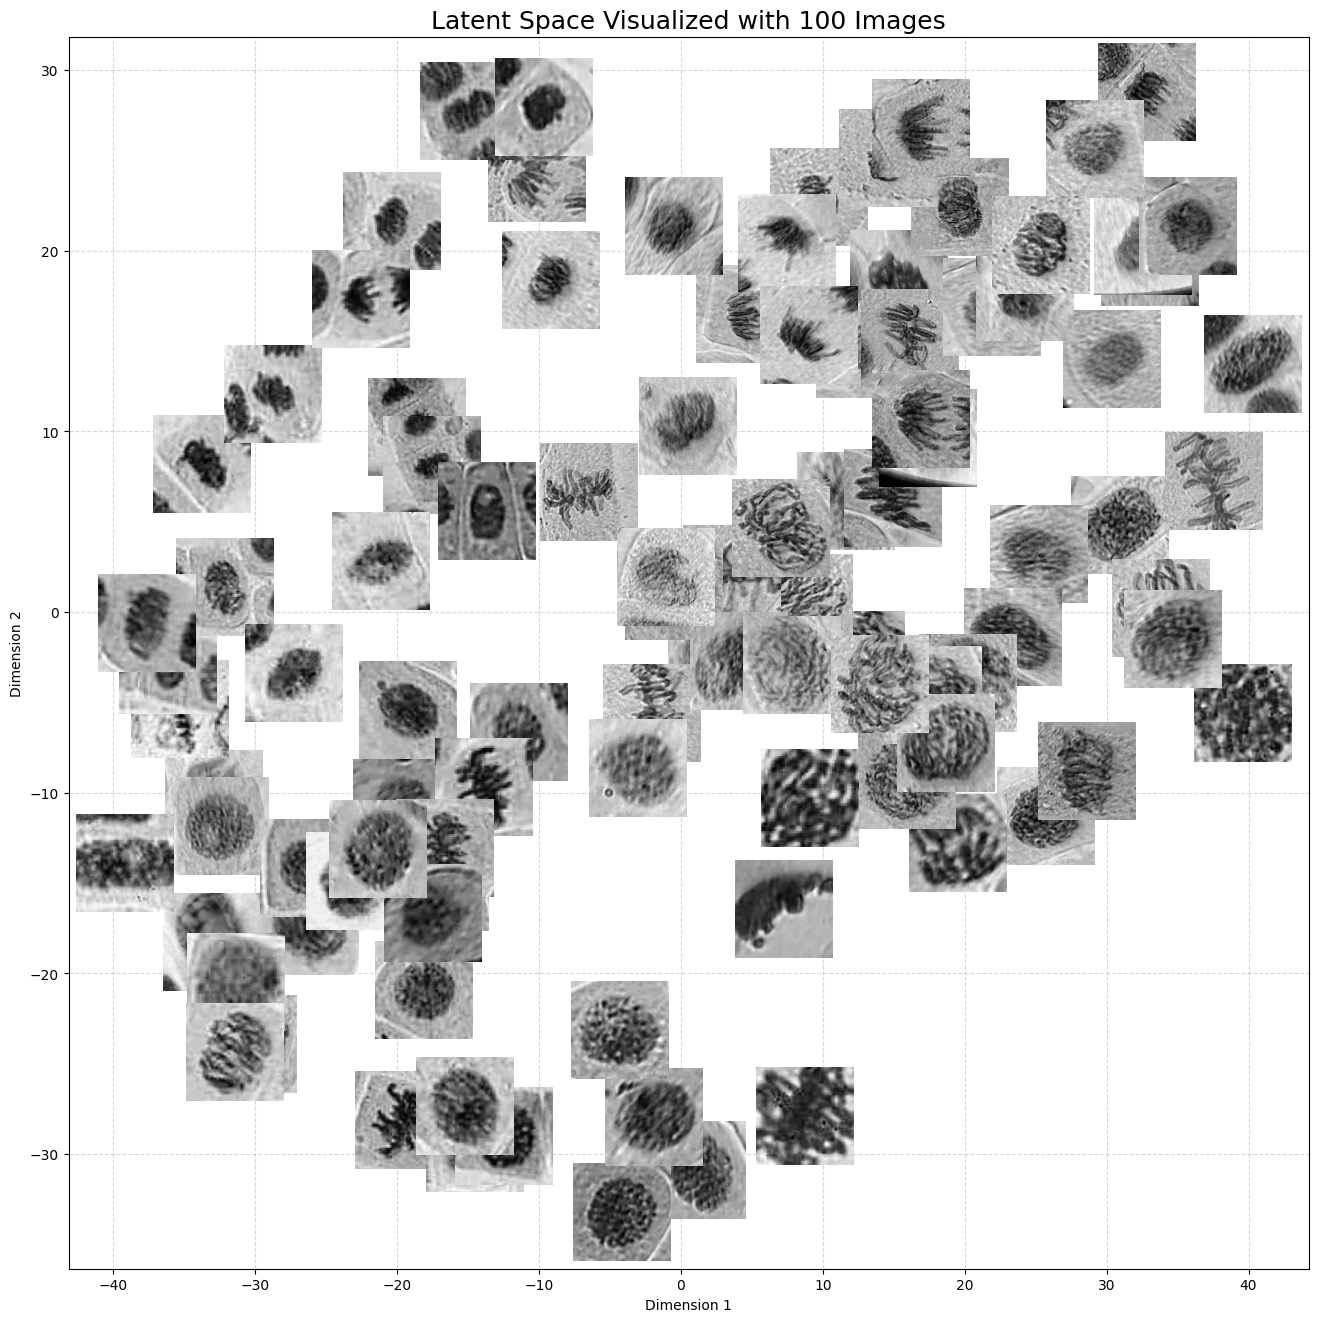

In [65]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

def plot_image_scatter(coords, images, zoom=0.3, title=""):
    """
    Creates a scatter plot where each point is replaced by its corresponding image.
    
    Args:
        coords (np.array): A (N, 2) array of 2D coordinates.
        images (np.array): A (N, H, W, C) array of images.
        zoom (float): The zoom factor for the images.
        title (str): The title for the plot.
    """
    fig, ax = plt.subplots(figsize=(16, 16))
    
    # Iterate through each point and its corresponding image
    for xy_coord, img in zip(coords, images):
        # Create an OffsetImage for the image data
        imagebox = OffsetImage(img.squeeze(), zoom=zoom, cmap='gray')
        
        # Create an AnnotationBbox to place the image at the coordinate
        # This acts as a container for the image on the plot
        ab = AnnotationBbox(
            imagebox,
            xy_coord,
            frameon=False,  # No frame around the images
            pad=0.0         # No padding
        )
        ax.add_artist(ab)
        
    # Adjust the plot limits and appearance
    ax.update_datalim(coords)
    ax.autoscale_view()
    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- Example Usage ---

# 1. Select a random subset of your data for clarity and performance
num_to_plot = 100  # Adjust this number based on desired density
random_indices = np.random.choice(len(latent_2d_tsne), size=num_to_plot, replace=False)

subset_coords = latent_2d_tsne[random_indices]
subset_images = original_images[random_indices]

# 2. Call the function with the subset of data
plot_image_scatter(
    subset_coords, 
    subset_images, 
    zoom=0.35,  # You may need to adjust the zoom for your image size
    title=f"Latent Space Visualized with {num_to_plot} Images"
)